Import Necesssary Libraries

In [1]:
# For this part, I imported different metrics from sklearn as an extra, which differs from our original code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

1. Load Data

In [2]:
data = pd.read_csv("fish.csv")
data

,Brightness,Length,Class
0,0.098997,0.919097,-1
1,0.131920,0.876004,-1
2,0.107292,0.869420,-1
3,0.254836,0.869754,-1
4,0.053935,0.820370,-1
...,...,...,...
125,0.856920,0.291629,1
126,0.640030,0.279687,1
127,0.807887,0.279687,1
128,0.857253,0.169097,1


2. Explore Data

In [3]:
data.describe()

,Brightness,Length,Class
count,130.000000,130.000000,130.000000
mean,0.471258,0.541689,-0.123077
std,0.232285,0.209793,0.996236
min,0.053935,0.125670,-1.000000
25%,0.283333,0.378125,-1.000000
50%,0.451525,0.550000,-1.000000
75%,0.682868,0.702296,1.000000
max,0.959375,0.955903,1.000000


In [4]:
data['Class'].value_counts()

Class
-1    73
 1    57
Name: count, dtype: int64

3. Handle Missing Values

In [5]:
# we can check whether we have any missing values per column
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing values per column:
Brightness    0
Length        0
Class         0
dtype: int64

Total missing values: 0


In [6]:
# let's drop duplicate rows if any, and check the resulting matrix
data = data.drop_duplicates()
print(f"Shape after removing duplicates: {data.shape}")

# we can fill missing values with functions like mean, median, min, max.(I preferred to fill empty columns with mean value)
data = data.fillna(data.mean(numeric_only=True))
print(f"Missing values after handling: {data.isnull().sum().sum()}")

Shape after removing duplicates: (130, 3)
Missing values after handling: 0


4. Visualize Features

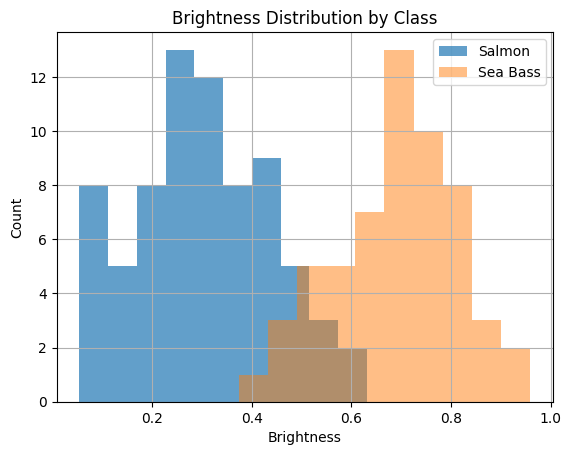

In [7]:
# I have used different titles and alpha values for this task.
data.loc[data["Class"] == -1, "Brightness"].hist(label="Salmon", alpha=0.7)
data.loc[data["Class"] == 1, "Brightness"].hist(label="Sea Bass", alpha=0.5)
plt.xlabel("Brightness")
plt.ylabel("Count")
plt.title("Brightness Distribution by Class")
plt.legend()
plt.show()

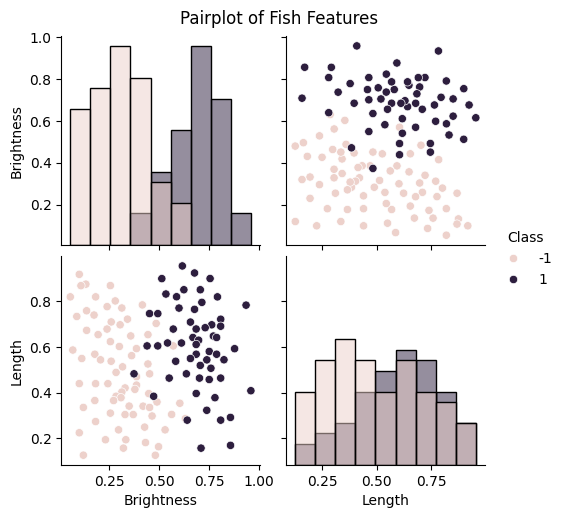

In [8]:
sns.pairplot(data, hue="Class", diag_kind="hist")
plt.suptitle("Pairplot of Fish Features", y=1.02)
plt.show()

5. Train-Test Split

In [9]:
# Defining split percentage
test_size = 0.2   # 20% for testing, 80% for training
random_state = 42  # for better reproducibility 

data_train, data_test = train_test_split(
    data,
    test_size= test_size,
    random_state= random_state,
    stratify=data["Class"]  # we are trying to keep class balance in both splits
)

In [10]:
# let us see the classes occuring in train and test sets
print("Class distribution in training set:")
print(data_train['Class'].value_counts())
print("\nClass distribution in test set:")
print(data_test['Class'].value_counts())

Class distribution in training set:
Class
-1    58
 1    46
Name: count, dtype: int64

Class distribution in test set:
Class
-1    15
 1    11
Name: count, dtype: int64


6. Feature Scaling (MinMaxScaler)

In [11]:
# scaling is also important for increasing the accuracy of our classification task.
features = ["Brightness", "Length"]

sc = MinMaxScaler()
sc.fit(data_train[features])

data_train = data_train.copy() # move training data from above cells 
data_test  = data_test.copy() # move testing data from above cells

# apply transformations for both of these parts of the data set. 
data_train.loc[:, features] = sc.transform(data_train[features])
data_test.loc[:, features]  = sc.transform(data_test[features])

print("Scaled test Length stats:")
data_test["Length"].describe()

Scaled test Length stats:


count    26.000000
mean      0.480481
std       0.241022
min       0.045198
25%       0.278230
50%       0.542808
75%       0.635478
max       0.903764
Name: Length, dtype: float64

7. Train KNN Classifier

In [12]:
# defining the number of neighbors
n_neighbors = 10  # we can change this value in order to tune our model

model = KNeighborsClassifier(n_neighbors= n_neighbors)
model.fit(data_train[features], data_train["Class"])

print(f"KNN model trained with n_neighbors = {n_neighbors}")

KNN model trained with n_neighbors = 10


8. Predict & Visualize Results

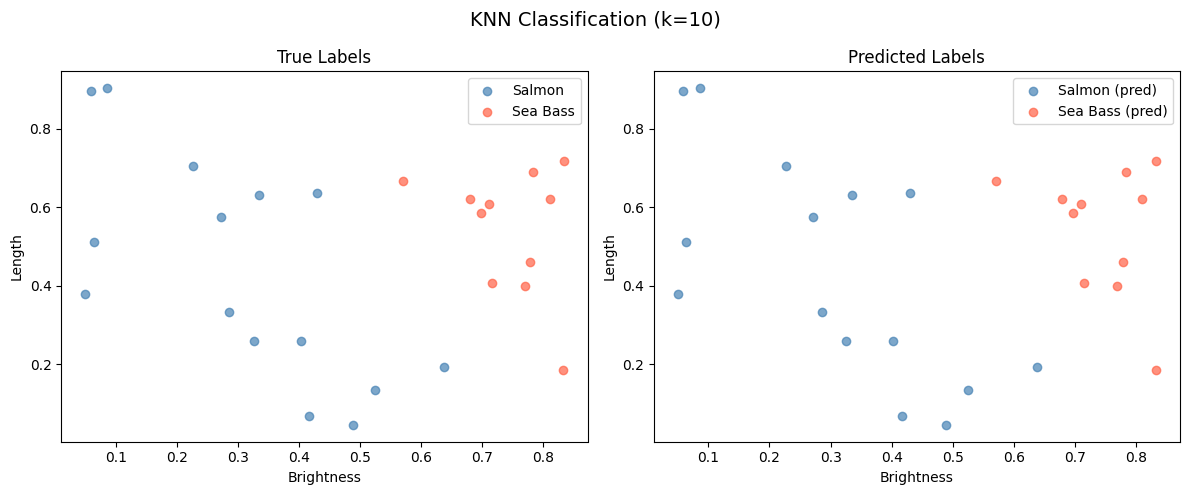

In [13]:
y_pred = model.predict(data_test[features])
y_true = data_test["Class"].values

# Scatter plot: true labels vs predicted labels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# True labels
for cls, label, color in [(-1, 'Salmon', 'steelblue'), (1, 'Sea Bass', 'tomato')]:
    mask = y_true == cls
    axes[0].scatter(
        data_test.loc[mask, 'Brightness'],
        data_test.loc[mask, 'Length'],
        label=label, alpha=0.7, c=color
    )
axes[0].set_title('True Labels')
axes[0].set_xlabel('Brightness')
axes[0].set_ylabel('Length')
axes[0].legend()

# Predicted labels
for cls, label, color in [(-1, 'Salmon (pred)', 'steelblue'), (1, 'Sea Bass (pred)', 'tomato')]:
    mask = y_pred == cls
    axes[1].scatter(
        data_test.loc[mask, 'Brightness'],
        data_test.loc[mask, 'Length'],
        label=label, alpha=0.7, c=color
    )
axes[1].set_title('Predicted Labels')
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Length')
axes[1].legend()

plt.suptitle(f'KNN Classification (k={n_neighbors})', fontsize=14)
plt.tight_layout()
plt.show()

9. Model Evaluation – Multiple Metrics

In [14]:
# For this part, I added different metrics from accuracy score for measuring the performance of our model.
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy  : {acc:.4f}")

# precision score
prec = precision_score(y_true, y_pred)
print(f"Precision : {prec:.4f}")

# recall score
rec = recall_score(y_true, y_pred)
print(f"Recall    : {rec:.4f}")

# f1-test score
f1 = f1_score(y_true, y_pred)
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


10. Compare The Performance of Algorithm with Different K Values

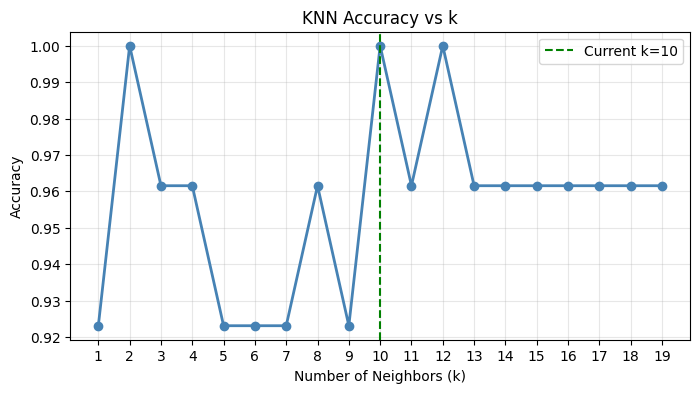

Best k = 2 with accuracy = 1.0000


In [15]:
# and finally, I added a graph, which indicates the change in accuracy, compared to the number of k for knn algorithm.
k_values = range(1, 20)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(data_train[features], data_train["Class"])
    preds = knn.predict(data_test[features])
    accuracies.append(accuracy_score(y_true, preds))

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.axvline(x= n_neighbors, color='green', linestyle='--', label=f'Current k={n_neighbors}')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best k = {best_k} with accuracy = {max(accuracies):.4f}")

In [16]:
%pip install nbconvert

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
!jupyter nbconvert --to html MLS2_Unit1_updated.ipynb

[NbConvertApp] Converting notebook MLS2_Unit1_updated.ipynb to html
C:\Users\arsan\AppData\Local\Programs\Python\Python314\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 531881 bytes to MLS2_Unit1_updated.html
